In [1]:
import warnings
warnings.filterwarnings("ignore") #supressing warnings because numpy and M4s result in matmul divide by 0 errors that should not exist

In [2]:
import os, sys
import numpy as np
import pandas as pd

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# stats stuff
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy import stats
from scipy.stats import pearsonr, spearmanr

# pca stuff
from sklearn.decomposition import PCA


In [3]:
ROOT_DIR    = os.path.abspath('..')

In [4]:
#parcellation = "aparc"
parcellation = "HCP.fsaverage.aparc"
#parcellation = "Schaefer_200"

In [5]:
# set minimum number of vertices based on parcellation (manual for now)
match parcellation:
    case "aparc":
        n_minimum = 200
    case "HCP.fsaverage.aparc":
        n_minimum = 100
    case "Schaefer_200":
        n_minimum = 2

In [6]:
#META_PATH   = os.path.join(ROOT_DIR, 'mind-test', 'healthy_eids.csv')
MAIN_DIR = os.path.join(ROOT_DIR, 'mind-test')
DATA_DIR    = os.path.join(ROOT_DIR, 'mind-test', 'test_dataset')
PLOT_DIR = os.path.join(ROOT_DIR, 'mind-test', f'plots_{parcellation}')
os.makedirs(PLOT_DIR, exist_ok=True)

In [7]:
from src.MIND_helpers_2026 import calculate_mind_network, calculate_mind_network_fast, get_qc_data
from src.MIND_2026 import compute_MIND
from src.convert_to_mgz import convert_to_mgz
from src.get_vertex_df import get_vertex_df
from src.filter_scale_vertex_data import filter_vertex_data, scale_vertex_data
from src import plots

In [8]:
def plot_qc(qc_dataframe, roi_qc):
    uniq = roi_qc['n_identical_values'].unstack('feature')
    zero = roi_qc['n_zero_values'].unstack('feature')
    outl = roi_qc['n_outliers'].unstack('feature')

    rois = uniq.index.astype(str)
    x = np.arange(len(rois))

    n_feat = uniq.shape[1]
    fig, axes = plt.subplots(3 * n_feat, 1, figsize=(14, 4 * n_feat * 1.5), sharex=True)
    axes = np.atleast_1d(axes)

    def fmt_c(val):
        return "N/A" if pd.isna(val) else f"{val:.3f}"

    for i, feat in enumerate(uniq.columns):
        ax_u, ax_z, ax_o = axes[3 * i], axes[3 * i + 1], axes[3 * i + 2]

        c_identical = qc_dataframe.loc[feat, 'C_n_identical_values']
        c_zero = qc_dataframe.loc[feat, 'C_n_zero_values']
        c_outliers = qc_dataframe.loc[feat, 'C_n_outliers']

        ax_u.bar(x, uniq[feat], color='tab:blue')
        ax_u.set_ylabel('n identical')
        ax_u.set_title(f'{feat}  (C = {fmt_c(c_identical)})')

        ax_z.bar(x, zero[feat], color='tab:orange')
        ax_z.set_ylabel('n zero')
        ax_z.set_title(f'C = {fmt_c(c_zero)}', fontsize=9, loc='right')

        ax_o.bar(x, outl[feat], color='tab:green')
        ax_o.set_ylabel('n outliers')
        ax_o.set_title(f'C = {fmt_c(c_outliers)}', fontsize=9, loc='right')

    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(rois, rotation=90, fontsize=7)
    axes[-1].set_xlabel('ROI')

    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, 'COMBO_roi.png'))
    plt.show()

In [9]:
def resolve_features(feature_list, custom_dirs):
    resolved = []
    for f in feature_list:
        if f in custom_dirs:
            resolved.append(f'{custom_dirs[f]}/?h.{f}.mgz')
        else:
            resolved.append(f)  # leave features that don't need custom tmp directory
    return resolved

In [10]:
surf_dir = os.path.join(DATA_DIR, "mystery_man", "surfaces", "mystery_man")
macro_features = ["CT", "MC", "Vol", "SD", "SA"]

In [11]:
MIND, qc_dataframe, roi_qc = compute_MIND(surf_dir, macro_features, parcellation, n_jobs=2, filter_vertices=False)

lh
Loading left hemisphere data:
/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/test_dataset/mystery_man/surfaces/mystery_man/surf/lh.thickness
/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/test_dataset/mystery_man/surfaces/mystery_man/surf/lh.curv
/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/test_dataset/mystery_man/surfaces/mystery_man/surf/lh.volume
/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/test_dataset/mystery_man/surfaces/mystery_man/surf/lh.sulc
/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/test_dataset/mystery_man/surfaces/mystery_man/surf/lh.area
['Feature_0', 'Feature_1', 'Feature_2', 'Feature_3', 'Feature_4']
0 Feature_0
1 Feature_1
2 Feature_2
3 Feature_3
4 Feature_4
rh
Loading right hemisphere data:


In [12]:
print(roi_qc.head())

                n_zero_values  n_identical_values  n_outliers  n_vertices
roi    feature                                                           
lh_??? CT                5635                5635           0        8821
       MC                   0                   1           7        8821
       Vol               6577                6576           1        8821
       SD                   0                   2           0        8821
       SA                   0                   3           5        8821


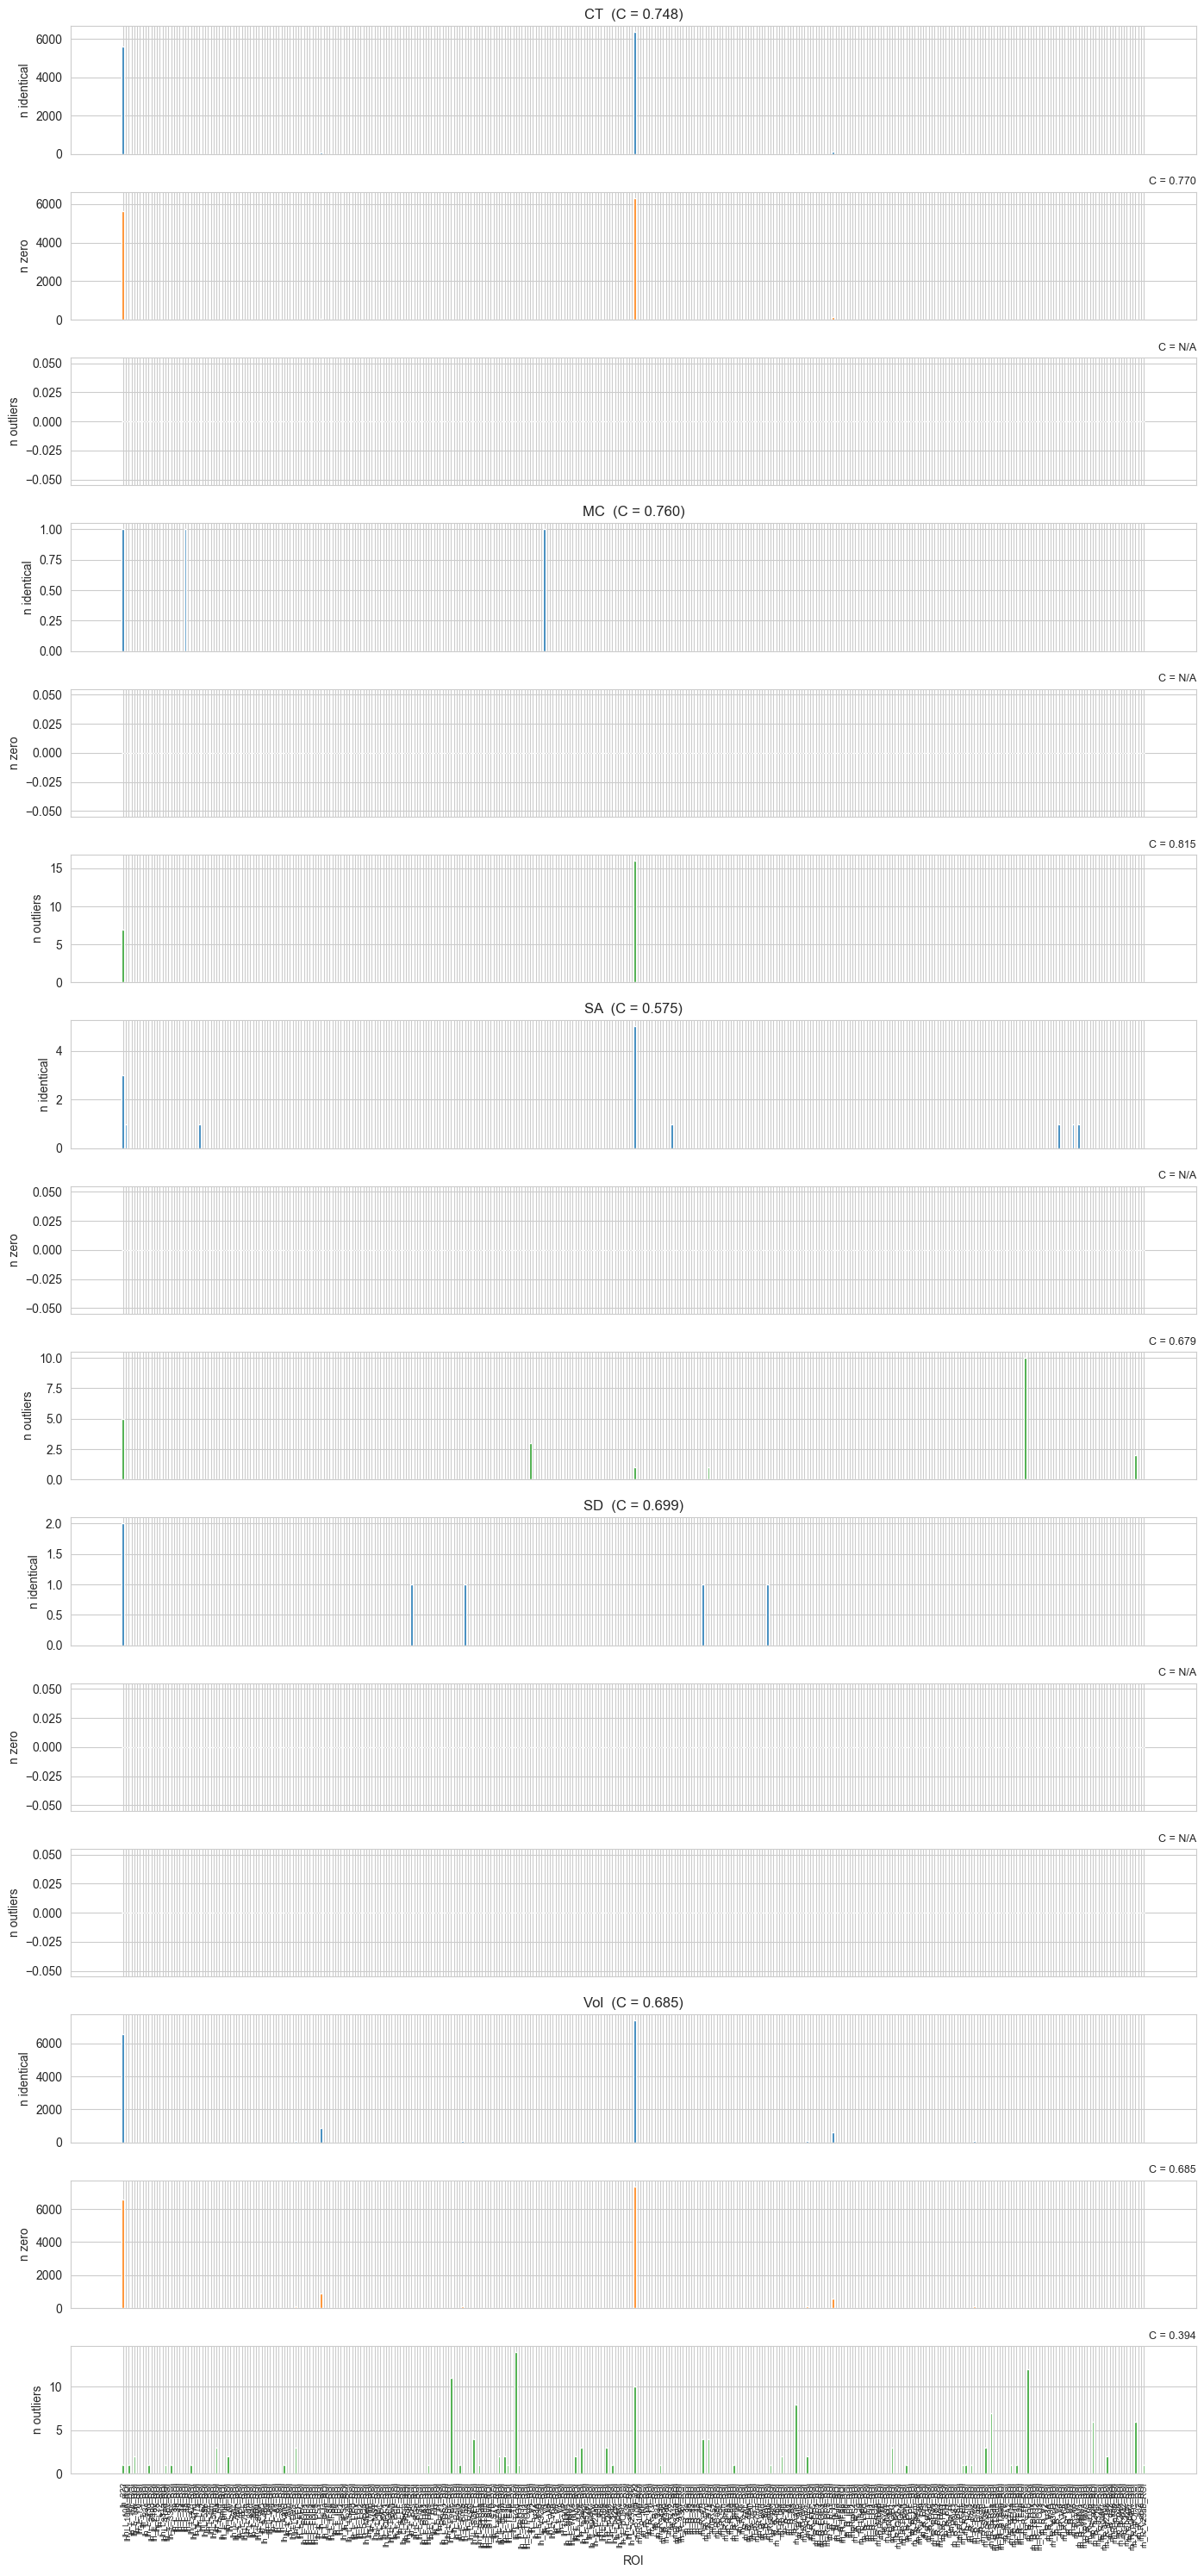

In [13]:
plot_qc(qc_dataframe, roi_qc)

## Check full computation

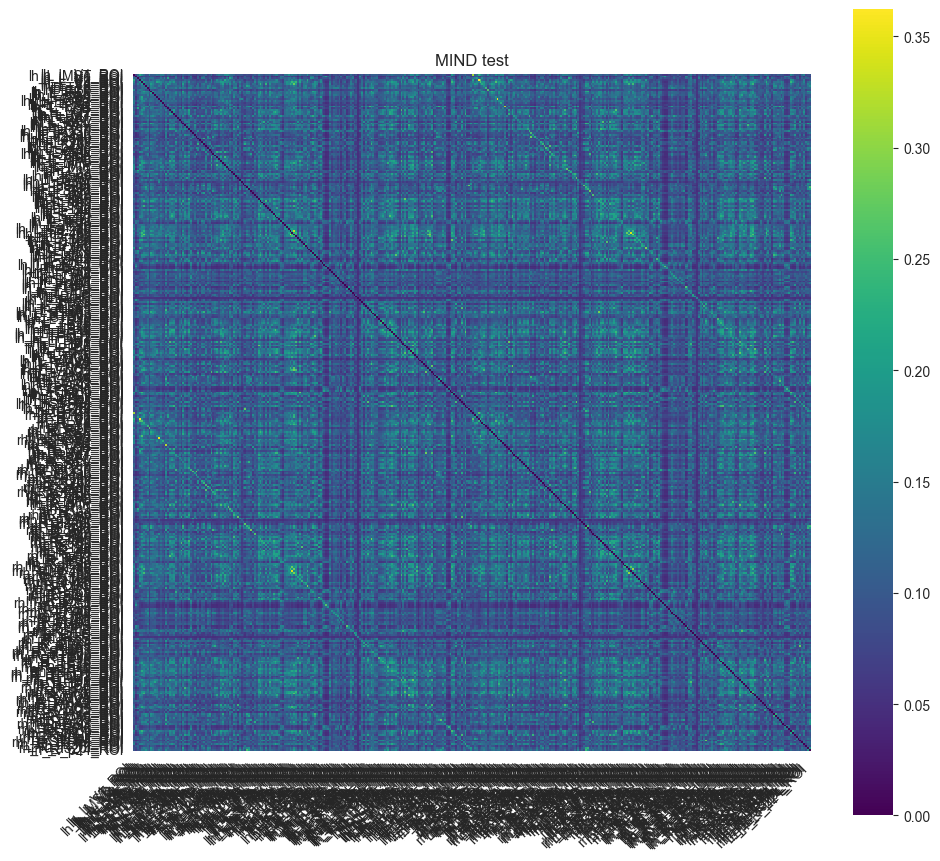

In [14]:
plt.figure(figsize=(10, 9))
sns.heatmap(MIND, xticklabels=True, yticklabels=True, cmap='viridis', square=True)
plt.xticks(rotation=45, ha='right')
plt.title('MIND test')
plt.tight_layout()
plt.show()

## DWI DATA - check functions

In [15]:
# Path to FreeSurfer subject directory (needed for parcellation .annot files)
path_to_surf_dir = surf_dir

# Path to the vol2surf_DWI surface outputs for this subject
vol2surf_dir = os.path.join(DATA_DIR, "mystery_man", "surfaces", "vol2surf_DWI", "surface")
tmp_dir = os.path.join(MAIN_DIR, 'tmp_mgz', 'mystery_man')

# DWI metrics available in vol2surf_DWI/surface/
features = {
    'FA':    'dti_FA_T1space_al2std60_back2sub',
    'MD':    'dti_MD_T1space_al2std60_back2sub',
    'ICVF':  'NODDI_ICVF_T1space_al2std60_back2sub',
    'ISOVF': 'NODDI_ISOVF_T1space_al2std60_back2sub',
    'OD':    'NODDI_OD_T1space_al2std60_back2sub',
}

custom_feature_dirs = convert_to_mgz(tmp_dir,
                                vol2surf_dir,
                                path_to_surf_dir,
                                parcellation,
                                features)


  FA: ready
  MD: ready
  ICVF: ready
  ISOVF: ready
  OD: ready

Using 5 DWI features: ['FA', 'MD', 'ICVF', 'ISOVF', 'OD']
Found parcellation .annot files in /Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/test_dataset/mystery_man/surfaces/mystery_man/label


In [16]:
features_list = ["FA", "MD", "ICVF", "ISOVF", "OD"]
features2use = resolve_features(features_list, custom_dirs=custom_feature_dirs)
print(features2use)

['/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/tmp_mgz/mystery_man/?h.FA.mgz', '/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/tmp_mgz/mystery_man/?h.MD.mgz', '/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/tmp_mgz/mystery_man/?h.ICVF.mgz', '/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/tmp_mgz/mystery_man/?h.ISOVF.mgz', '/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/tmp_mgz/mystery_man/?h.OD.mgz']


In [17]:
DTI_MIND, qc_dataframe, roi_qc = compute_MIND(path_to_surf_dir, features2use, parcellation, micro=True, n_jobs=2, filter_vertices=False)

lh
Loading left hemisphere data:
/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/tmp_mgz/mystery_man/lh.FA.mgz
/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/tmp_mgz/mystery_man/lh.MD.mgz
/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/tmp_mgz/mystery_man/lh.ICVF.mgz
/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/tmp_mgz/mystery_man/lh.ISOVF.mgz
/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/tmp_mgz/mystery_man/lh.OD.mgz
['Feature_0', 'Feature_1', 'Feature_2', 'Feature_3', 'Feature_4']
0 Feature_0
1 Feature_1
2 Feature_2
3 Feature_3
4 Feature_4
rh
Loading right hemisphere data:
['Feature_0', 'Feature_1', 'Feature_2', 'Feature_3', 'Feature_4']
0 Feature_0
1 Feature_1
2 Feature_2
3 Feature_3
4 Feature_4
features used: 
['Fea

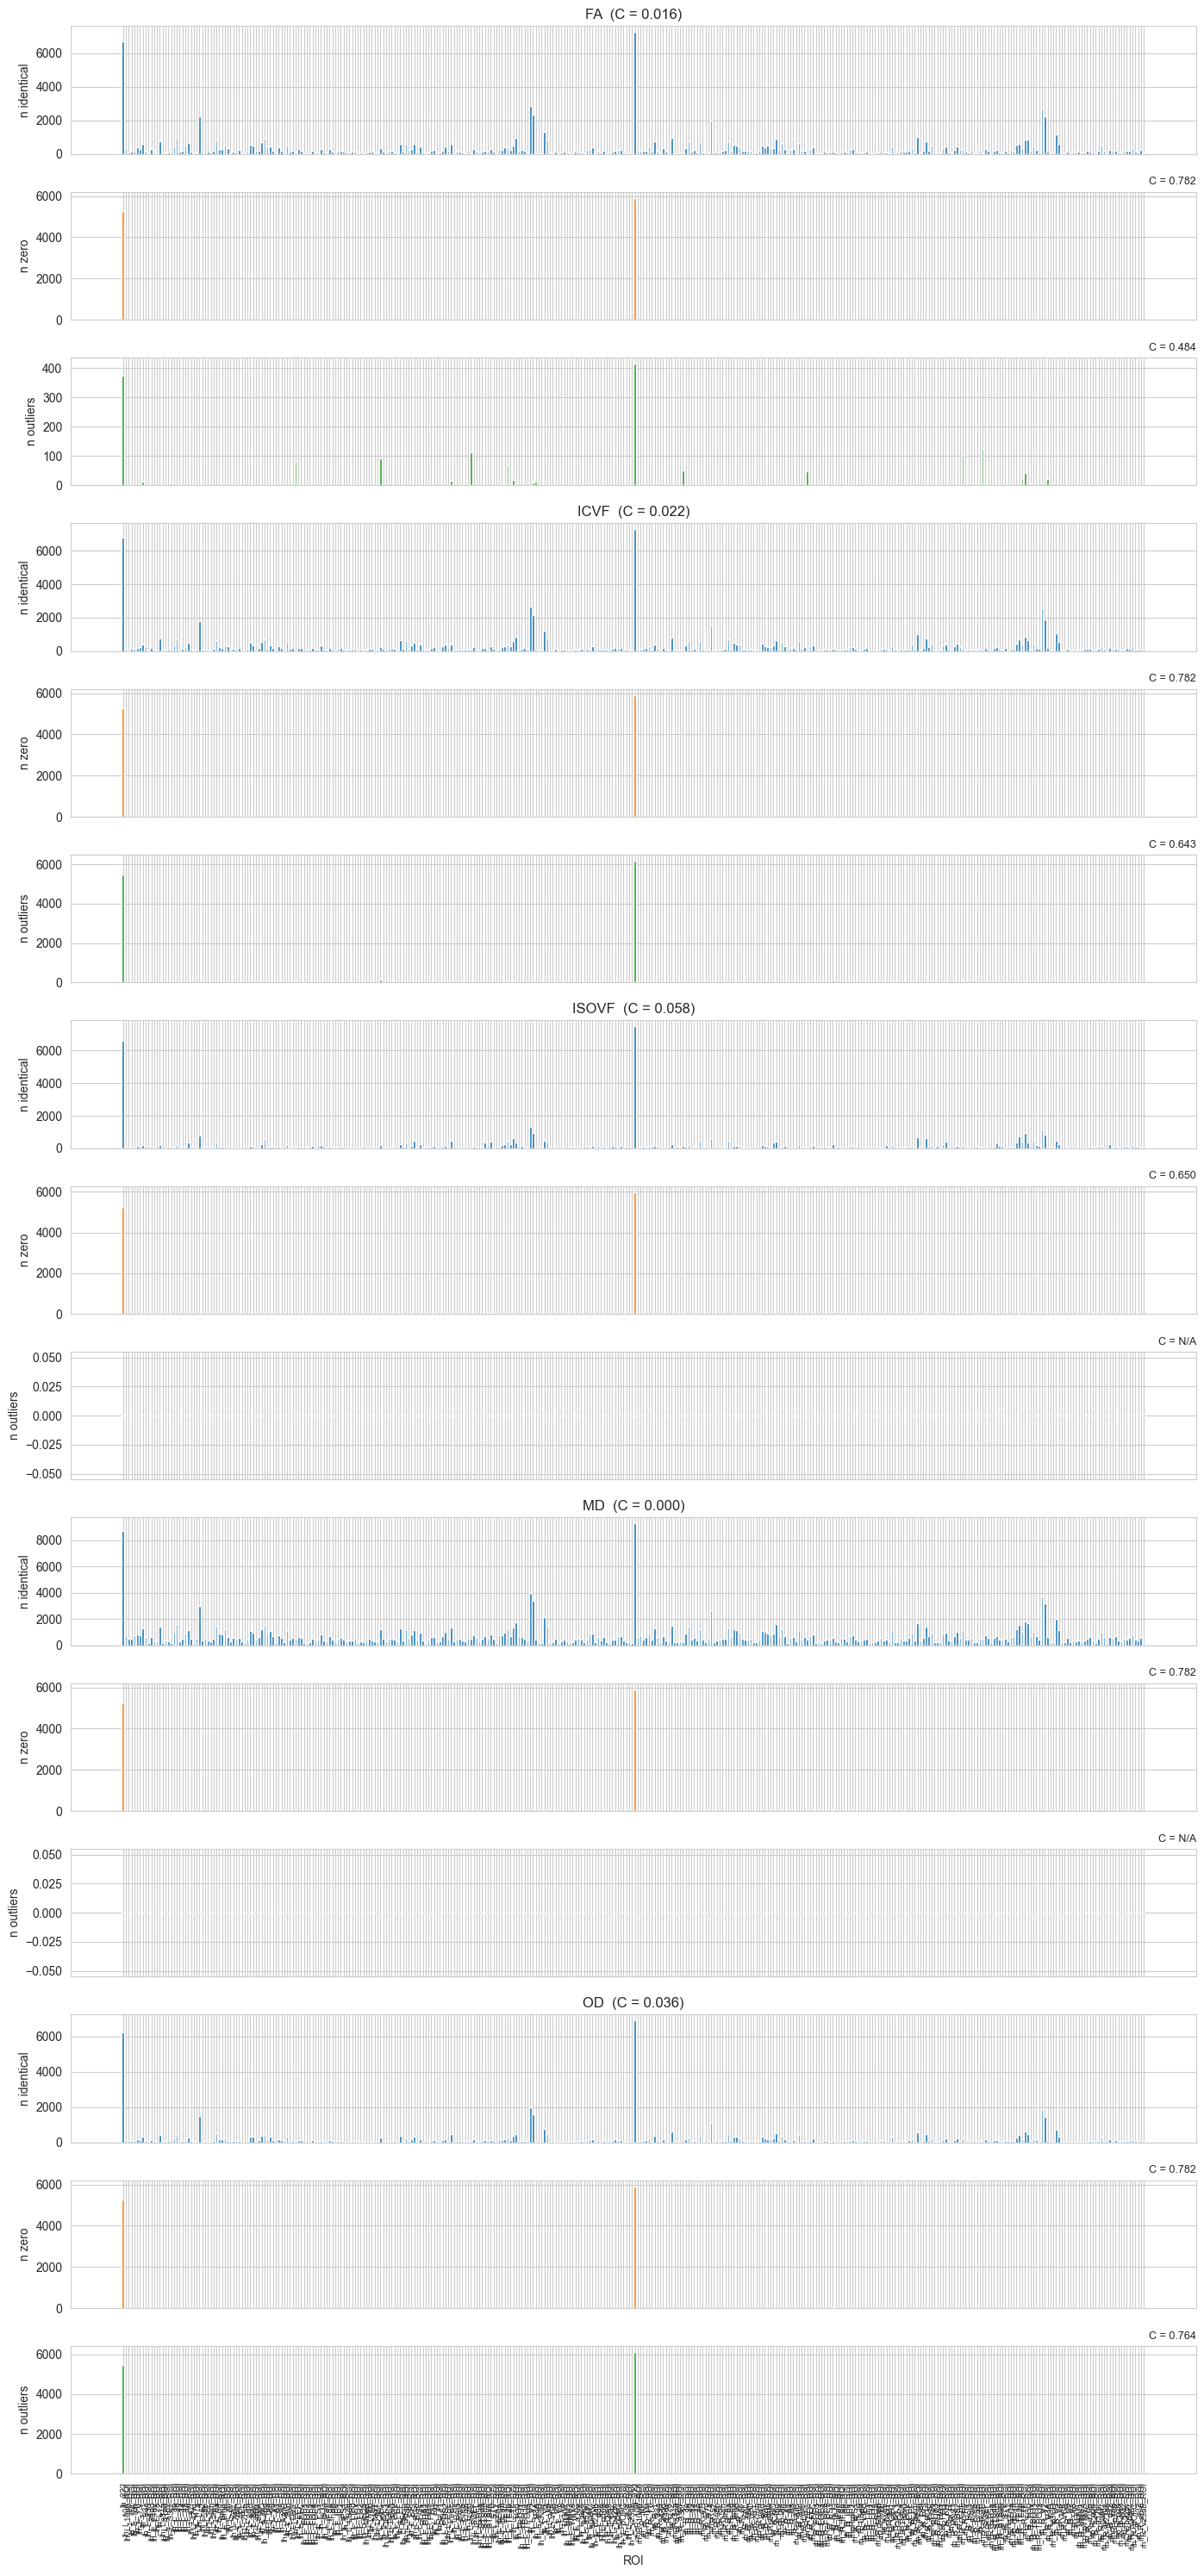

In [18]:
plot_qc(qc_dataframe, roi_qc)

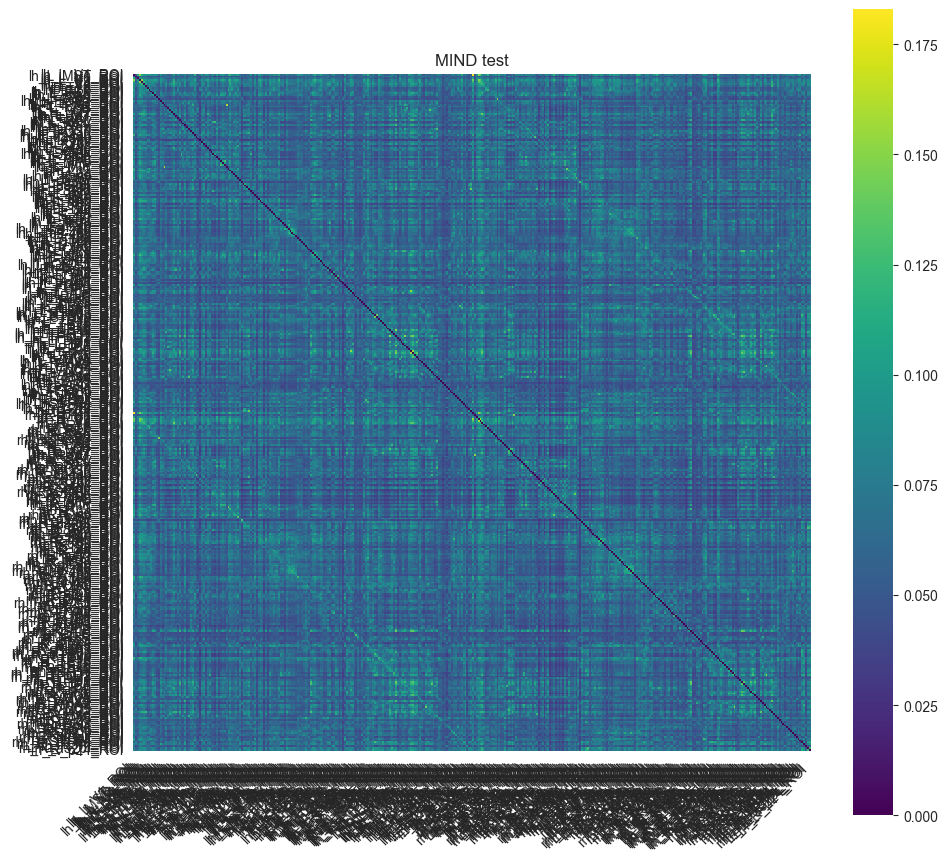

In [19]:
plt.figure(figsize=(10, 9))
sns.heatmap(DTI_MIND, xticklabels=True, yticklabels=True, cmap='viridis', square=True)
plt.xticks(rotation=45, ha='right')
plt.title('MIND test')
plt.tight_layout()
plt.show()

# Check univariate MIND

In [20]:
UNI_MIND, qc_dataframe, roi_qc = compute_MIND(surf_dir, ["CT"], parcellation, resample=True, n_jobs=2, filter_vertices=False)

lh
Loading left hemisphere data:
/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/test_dataset/mystery_man/surfaces/mystery_man/surf/lh.thickness
['Feature_0']
0 Feature_0
rh
Loading right hemisphere data:
['Feature_0']
0 Feature_0
features used: 
['Feature_0']
Computing MIND...
Computing 64620 region pairs across 2 cores...
Done!
MIND computation: 147.7s


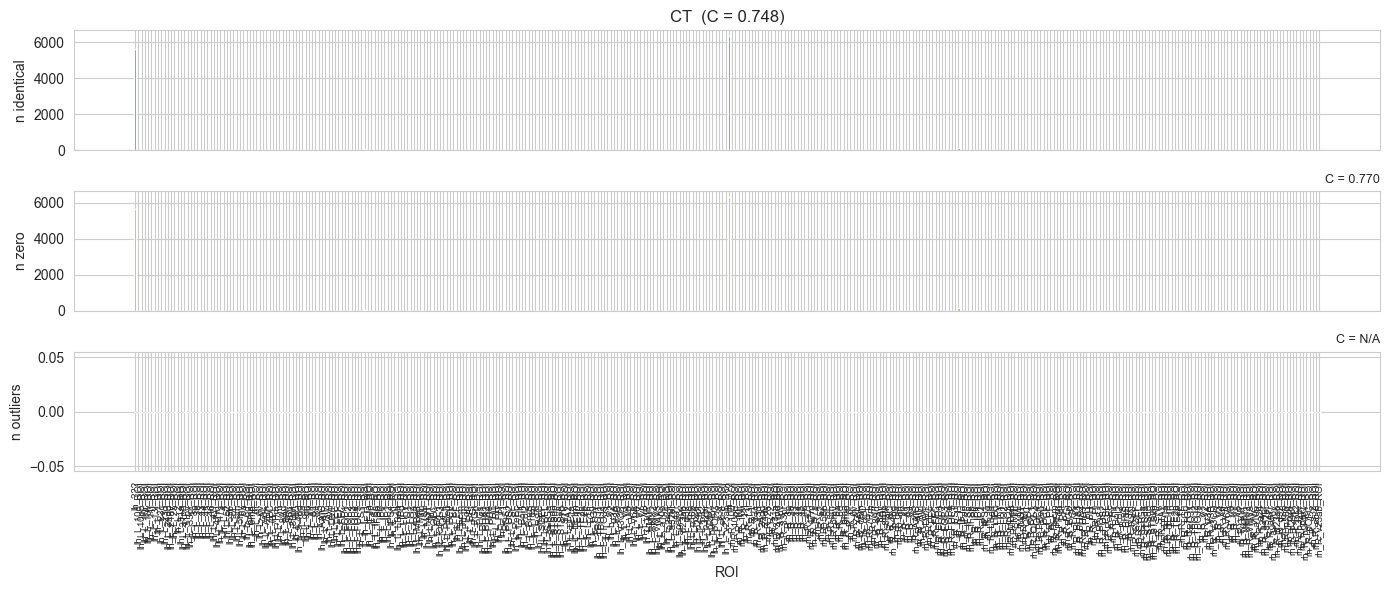

In [21]:
plot_qc(qc_dataframe, roi_qc)

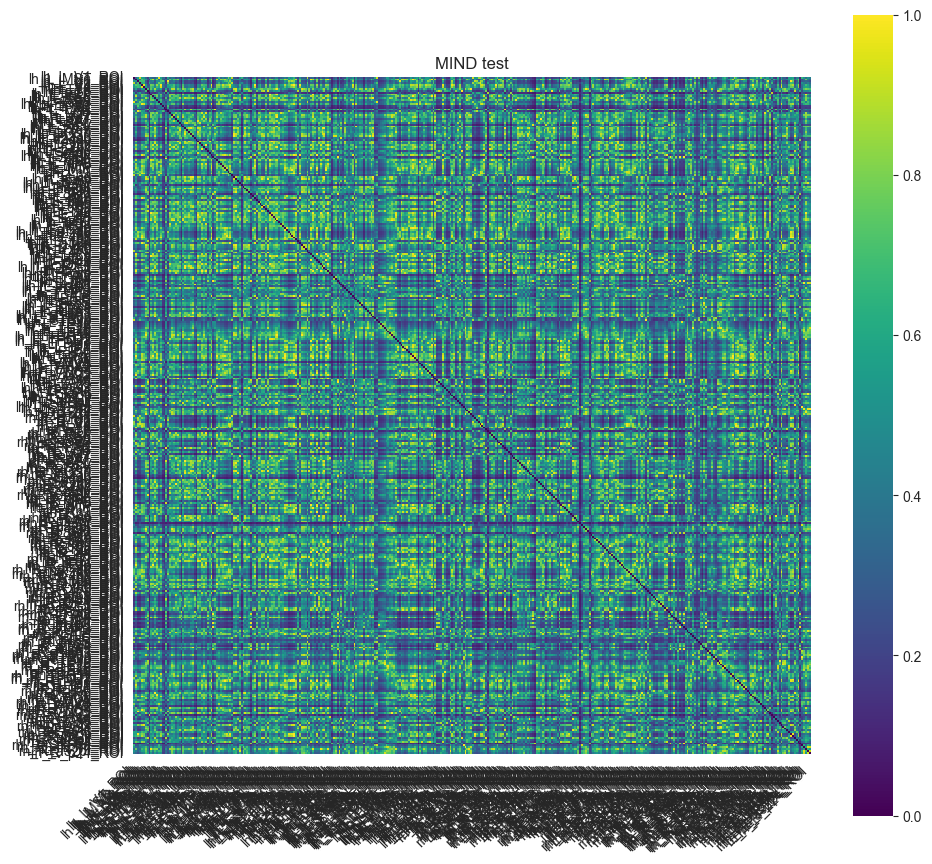

In [22]:
plt.figure(figsize=(10, 9))
sns.heatmap(UNI_MIND, xticklabels=True, yticklabels=True, cmap='viridis', square=True)
plt.xticks(rotation=45, ha='right')
plt.title('MIND test')
plt.tight_layout()
plt.show()

## CHECK MICRO AND MACRO COMBINED

In [23]:
features_list = ["FA", "MD", "ICVF", "ISOVF", "OD"] + macro_features
features2use = resolve_features(features_list, custom_dirs=custom_feature_dirs)

In [24]:
features2use

['/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/tmp_mgz/mystery_man/?h.FA.mgz',
 '/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/tmp_mgz/mystery_man/?h.MD.mgz',
 '/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/tmp_mgz/mystery_man/?h.ICVF.mgz',
 '/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/tmp_mgz/mystery_man/?h.ISOVF.mgz',
 '/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/tmp_mgz/mystery_man/?h.OD.mgz',
 'CT',
 'MC',
 'Vol',
 'SD',
 'SA']

In [25]:
COMBO_MIND, qc_dataframe, roi_qc = compute_MIND(path_to_surf_dir, features2use, parcellation, micro=True, n_jobs=2, filter_vertices=False)

lh
Loading left hemisphere data:
/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/tmp_mgz/mystery_man/lh.FA.mgz
/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/tmp_mgz/mystery_man/lh.MD.mgz
/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/tmp_mgz/mystery_man/lh.ICVF.mgz
/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/tmp_mgz/mystery_man/lh.ISOVF.mgz
/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/tmp_mgz/mystery_man/lh.OD.mgz
/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/test_dataset/mystery_man/surfaces/mystery_man/surf/lh.thickness
/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/test_dataset/mystery_man/surfaces/mystery

In [26]:
print(qc_dataframe)

         n_total  n_outliers  n_identical_values  n_zero_values  C_n_outliers  \
feature                                                                         
FA        253662        1661              249944          11242      0.484472   
MD        253662           0              253429          11242           NaN   
ICVF      253662       12996              248052          11242      0.643280   
ISOVF     253662           0              243055          12346           NaN   
OD        253662       11763              247332          11242      0.763945   
CT        253662           0               15694          12152           NaN   
MC        253662          23                 528              0      0.814796   
Vol       253662         143               16856          15895      0.393819   
SD        253662           0                 535              0           NaN   
SA        253662          22                1850              0      0.679452   

         C_n_identical_valu

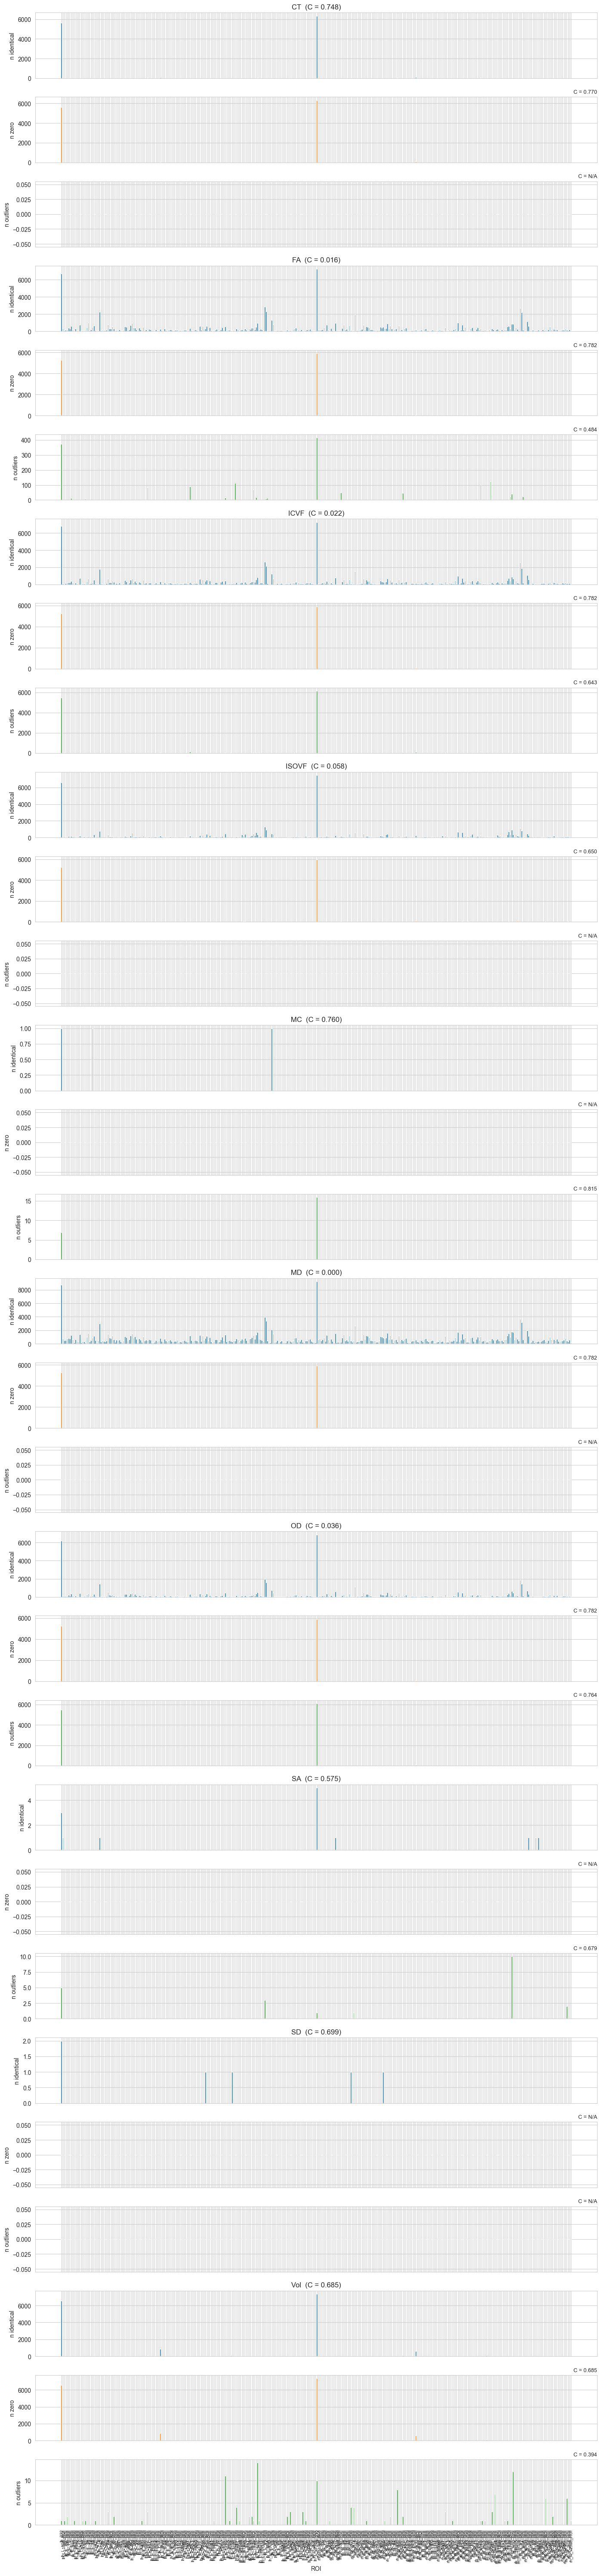

In [27]:
plot_qc(qc_dataframe, roi_qc)

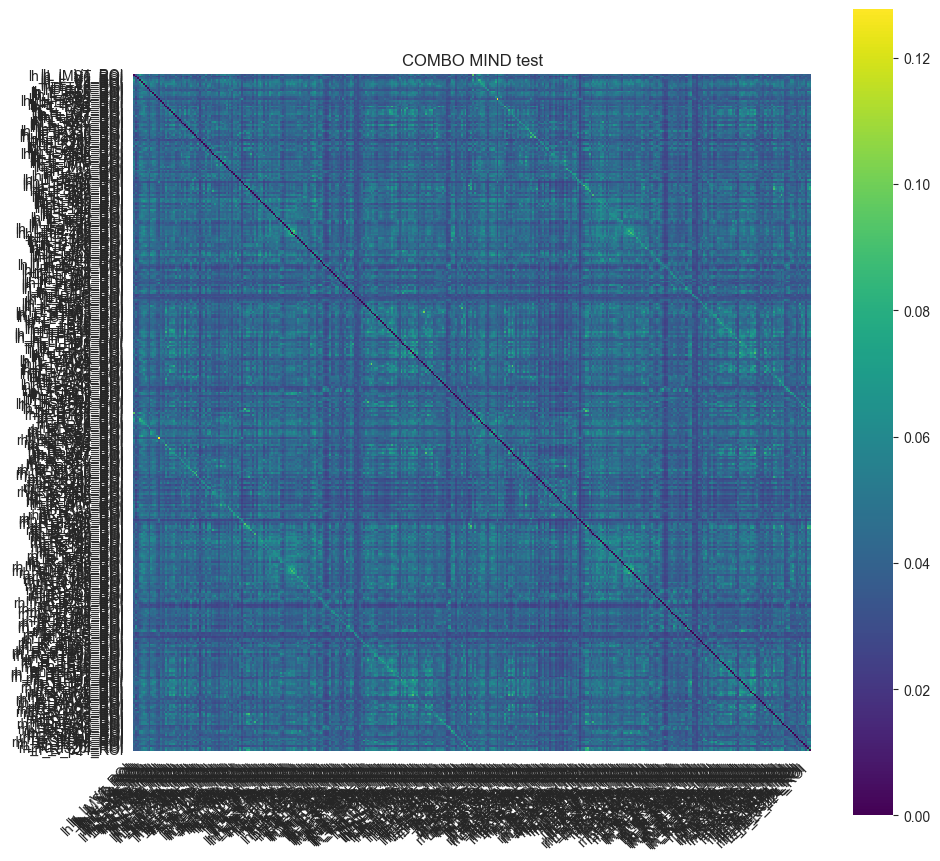

In [28]:
plt.figure(figsize=(10, 9))
sns.heatmap(COMBO_MIND, xticklabels=True, yticklabels=True, cmap='viridis', square=True)
plt.xticks(rotation=45, ha='right')
plt.title('COMBO MIND test')
plt.tight_layout()
plt.show()